In [5]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

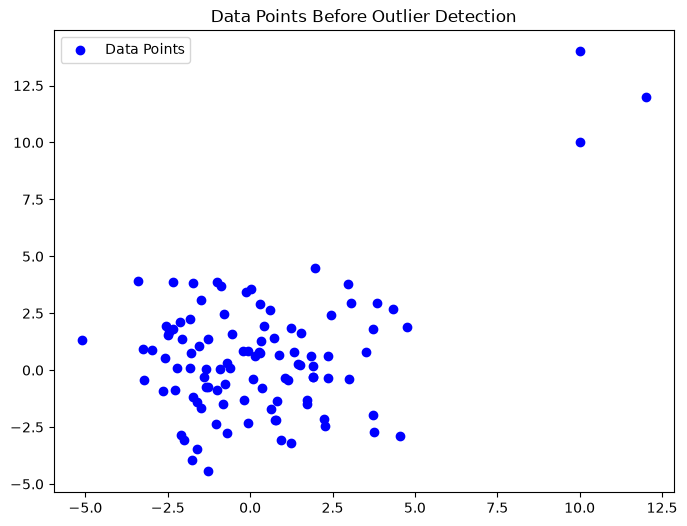

In [6]:
# Generating more sample data
np.random.seed(0)
X_normal = np.random.randn(100, 2) * 2
X_outliers = np.array([[10, 10], [12, 12], [10, 14]])
X = np.concatenate([X_normal, X_outliers], axis=0)

# Plot the data before outlier detection
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')
plt.title('Data Points Before Outlier Detection')
plt.legend()
plt.show()

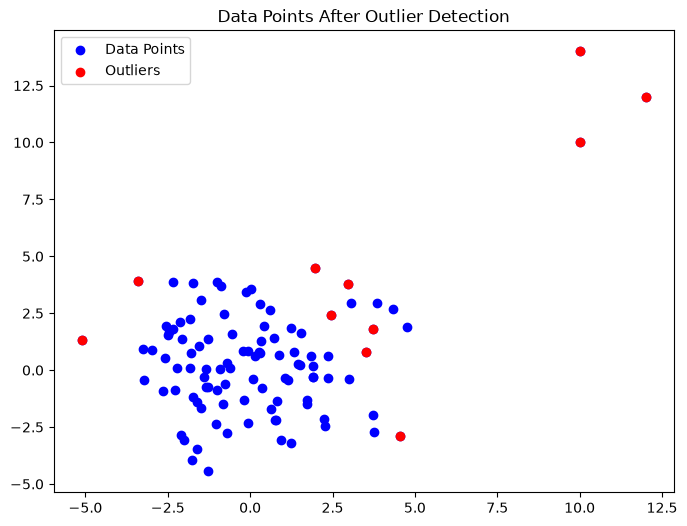

In [7]:
# Set the number of neighbors
k = 2

# Fit the model
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
distances, indices = nbrs.kneighbors(X)

# Calculate the outlier score
outlier_scores = np.mean(distances[:, 1:], axis=1)

# Determine a threshold
threshold = np.percentile(outlier_scores, 90)  # using the 95th percentile as the threshold

# Identify outliers
outlier_indices = np.where(outlier_scores > threshold)[0]
outliers = X[outlier_indices]

# Plot the data after outlier detection
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label='Outliers')
plt.title('Data Points After Outlier Detection')
plt.legend()
plt.show()

## This Technique struggles with local Outliers

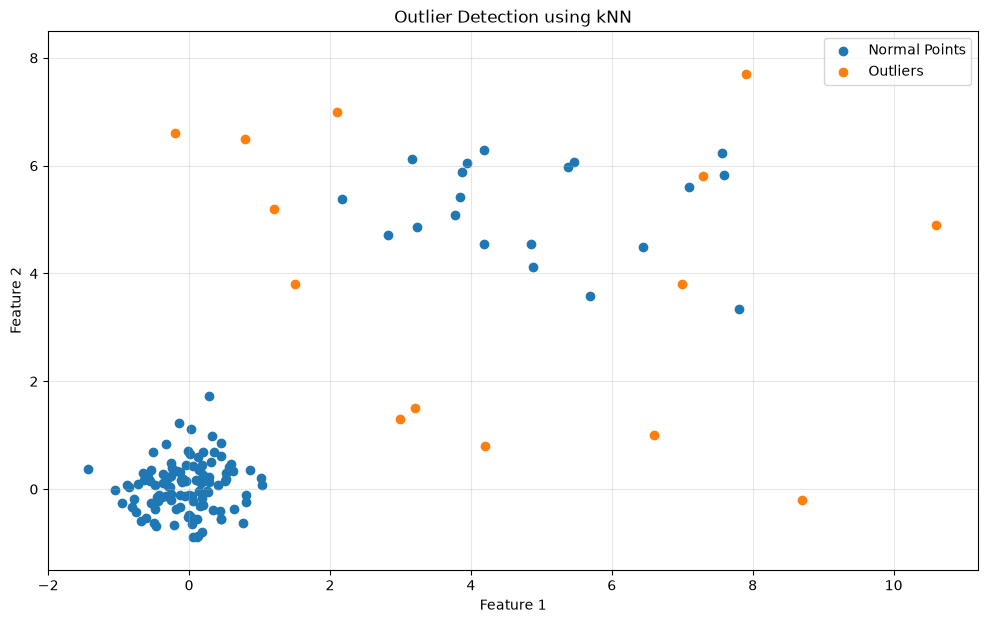

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

# -----------------------------
# 1. Generate normal points
# -----------------------------

# Dense cluster around (0, 0)
cluster_1 = np.random.normal(
    loc=[0, 0],
    scale=[0.55, 0.45],
    size=(110, 2)
)

# Smaller cluster in the upper region
cluster_2 = np.random.normal(
    loc=[4.8, 5.2],
    scale=[1.3, 1.0],
    size=(20, 2)
)

normal_data = np.vstack([cluster_1, cluster_2])


# -----------------------------
# 2. Generate outliers
# -----------------------------

outliers = np.array([
    [-0.2, 6.6],
    [0.8, 6.5],
    [1.2, 5.2],
    [1.5, 3.8],
    [2.1, 7.0],
    [3.0, 1.3],
    [3.2, 1.5],
    [4.2, 0.8],
    [6.6, 1.0],
    [7.0, 3.8],
    [7.3, 5.8],
    [7.9, 7.7],
    [8.7, -0.2],
    [10.6, 4.9]
])


# -----------------------------
# 3. Create dataset
# -----------------------------

data = pd.DataFrame(
    np.vstack([normal_data, outliers]),
    columns=["x1", "x2"]
)

data["label"] = (
    ["Normal"] * len(normal_data)
    + ["Outlier"] * len(outliers)
)


# -----------------------------
# 4. Plot the dataset
# -----------------------------

normal = data[data["label"] == "Normal"]
outlier = data[data["label"] == "Outlier"]

plt.figure(figsize=(12, 7))

plt.scatter(
    normal["x1"],
    normal["x2"],
    label="Normal Points"
)

plt.scatter(
    outlier["x1"],
    outlier["x2"],
    label="Outliers"
)

plt.title("Outlier Detection using kNN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.grid(alpha=0.3)

plt.xlim(-2, 11.2)
plt.ylim(-1.5, 8.5)

plt.show()